# 05 Simple Linear Regression

Simple Linear Regression memodelkan hubungan antara sebuah response variable dengan sebuah explanatory variable sebagai suatu garis lurus (linear)

Referensi : https://en.wikipedia.org/wiki/Simple_linear_regression

---

## Sample Dataset

Kita persiapkan terlebih dahulu dataset yang akan kita pergunakan dalam sesi pembelajaran kita kali ini. Nah disini kita akan membentuk dataset yang berisi daftar `diameter` pizza berserta `harga`-nya. Dataset ini akan kita tampung ke dalam format Pandas DataFrame. 

Pertama-tama kita import dulu modul Pandasnya.

In [1]:
import pandas as pd

Lalu disini kita siapkan suatu Dictionary yang terdiri dari dua buah **key** yaitu **diameter** dan **harga**. Dan setiap key-nya ini akan berasosiasi dengan List. Lalu berikutnya, Dictionary ini akan kita tampung kedalam variable `pizza` 

In [2]:
pizza = {
    'diameter' : [6, 8, 10, 14, 18],
    'harga' : [7, 9, 13, 17.5, 18]
}

In [3]:
pizza

{'diameter': [6, 8, 10, 14, 18], 'harga': [7, 9, 13, 17.5, 18]}

Selanjutnya kita bentuk sebagai objek DataFrame. Nah disini proses pembentukan DataFrame-nya bisa dilakukan dengan cara `pd.DataFrame` lalu kita menyertakan `pizza` tadi sebagai parameternya. Lalu kita tampung DataFrame-nya kedalam variable `pizza_df`

In [4]:
pizza_df = pd.DataFrame(pizza)

In [5]:
pizza_df

,diameter,harga
0,6,7.0
1,8,9.0
2,10,13.0
3,14,17.5
4,18,18.0


Kalau kita lihat, dataset kita kali ini terdiri dari 2 buah kolom, yaitu kolom `diameter` dan kolom `harga`. 

Nah dalam sesi pembelajaran kita kali ini, kita akan membentuk suatu model **Machine Learning Sederhana** yang dapat digunakan **untuk `memprediksi harga pizza bila diketahui ukuran diameter-nya`**.

Dengan kata lain, kolom `diameter` akan berperan sebagai **features**, sedangkan `harga` akan menjadi **target**. 

--- 

## Visualisasi Data

Disini kita akan visualisasikan dataset pizza yang telah kita bentuk sebelumnya kedalam scatterplot. Dimana sumbu `X` ini akan berasosiasi dengan `diameter` pizza sedangkan sumbu `y` ini akan berasosiasi dengan `harga` pizza.

In [6]:
import seaborn as sns

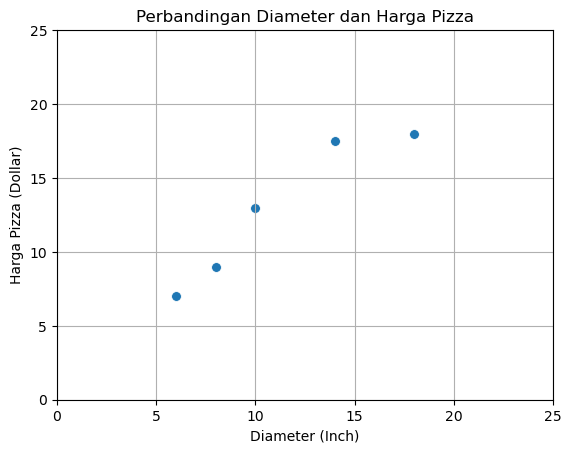

In [7]:
ax = sns.scatterplot(data=pizza_df, x='diameter', y='harga', s=50)

ax.set(
    title = 'Perbandingan Diameter dan Harga Pizza',
    xlabel = 'Diameter (Inch)',       # nama label sumbu X
    ylabel = 'Harga Pizza (Dollar)',  # nama label sumbu y
    xlim = (0, 25),  # lebar sumbu X kesamping kanan (0 sampai 25)
    ylim = (0, 25)   # panjang sumbu y keatas (0 sampai 25)
)

ax.grid(True)  # latar bergaris

Lalu berikutnya ada hal lain yang perlu kita perhatikan, setiap data point atau setiap marker berwarna biru akan mempresentasikan satu baris dari DataFrame yang kita miliki. kalau kita cek lagi datanya 

In [8]:
pizza_df

,diameter,harga
0,6,7.0
1,8,9.0
2,10,13.0
3,14,17.5
4,18,18.0


kalau kita lihat data kita terdiri dari 5 baris (index 0 sampai 4), begitu juga dengan titik biru (marker) pada visualisasi yang jumlahnya juga 5. Yang menandakan 1 baris pada `pizza_df` akan memvisualisasikan 1 titik biru pada scatter plot. 

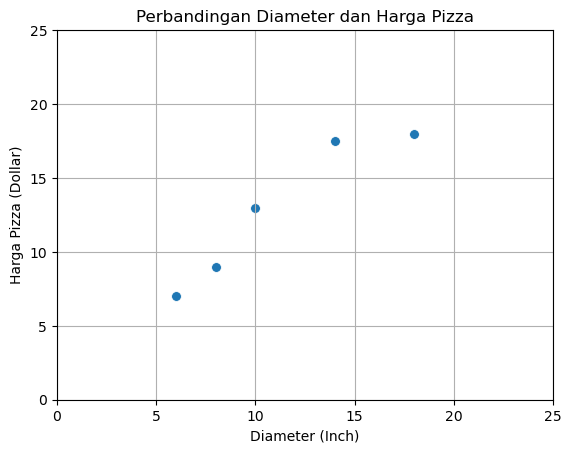

In [9]:
ax.figure

Kita balik lagi ke hasil visual, kalau kita perhatikan disini titik-titik biru diatas seolah-olah akan membentuk garis lurus jika kita tarik dari titik marker kiri bawah ke kanan atas. Nah ini merupakan kasus yang sangat tepat sekali untuk menerapkan Linear Regression. Karena model Linear Regression akan berkaitan dengan persamaan garis lurus. 

> Perlu saya ingatkan lagi terkait tujuan dari eksplorasi kita. **Tujuan disini adalah untuk mencoba memprediksi harga pizza bila diketahui diameternya**.
> Dan kita akan memecahkan masalah ini dengan memanfaatkan model Machine Learning, yaitu Simple Linear Regression.

---

# Simple Linear Regression Model

## Penyesuaian Dataset

Disini kita akan melakukan beberapa penyesuaian terhadap dataset pizza yang kita miliki. 

- Langkah pertama yang kita lakukan adalah mengelompokan feature dan target ke dalam dua variable terpisah. 
- Selain itu, kita akan melakukan konversi struktur data dari yang semula kita menggunakan Pandas DataFrame menjadi Numpy Array


In [10]:
import numpy as np

Lalu berikutnya untuk diameter, karena `diameter` ini merupakan feature, akan kita seleksi dulu, lalu kita konversikan menjadi suatu numpy array. Yang berikutnya akan kita tampung kedalam variable `X`. Dimana variable X ini akan kita pandang sebagai variable features. 

In [11]:
X = np.array(pizza_df['diameter'])

In [12]:
X

array([ 6,  8, 10, 14, 18])

Lalu berikutnya untuk kolom `harga` akan kita konversikan menjadi numpy array dan nilainya kita tampung ke dalam variable `y`. Nah variable `y` ini akan kita perlalukan sebagai variable target. 

In [13]:
y = np.array(pizza_df['harga'])

In [14]:
y

array([ 7. ,  9. , 13. , 17.5, 18. ])

In [15]:
print(f"X : {X}")
print(f"y : {y}")

X : [ 6  8 10 14 18]
y : [ 7.   9.  13.  17.5 18. ]


bisa kita lihat untuk `X` merupakan sekumpulan nilai **features** dan untuk `y` adalah sekumpulan nilai **target**.

Namun kalau kita perhatikan diatas, variable X yang digunakan untuk menampung features hanya terdiri dari satu dimensi saja (kesamping). Padahal dari sesi pembelajaran sebelumnya, kita mengetahui bahwa model machine learning yang disertakan dalam scikit-learn membutuhkan sekumpulan nilai features yang ditampung dalam satu array 2 dimensi (2D).

Oleh karenanya, kita disini perlu melakukan proses reshaping terhadap array yang digunakan untuk menampung nilai features. 

In [16]:
X = X.reshape(-1, 1)
X.shape

(5, 1)

Bisa dilihat setelah reshaping dimensinya sudah menjadi 5 baris dan 1 kolom. Dan kalau kita tampilkan 

In [17]:
X

array([[ 6],
       [ 8],
       [10],
       [14],
       [18]])

Itu dia hasilnya, kali ini variable X akan menampung suatu array 2 dimensi, dimana jumlah barisnya ada lima dan kolomnya ada satu. Nah proses transformasi dari :
```python
X : [ 6  8 10 14 18]
```

menjadi seperti ini :
```python
array([[ 6],
       [ 8],
       [10],
       [14],
       [18]])
```

dimungkinkan karena proses `.reshape(-1, 1)` tadi. 

---

## Training Simple Linear Regression Model

Pada kali ini kita akan proses dimana model yang kita pilih adalah Linear Regression. 

Pertama-tama kita import dulu estimator class-nya, dan estimator yang akan kita gunakan kali ini adalah Linear Reggresion. Caranya cukup panggil 

In [18]:
from sklearn.linear_model import LinearRegression

Nah berikutnya kita akan membuat objek model dari estimator class ini

In [19]:
model = LinearRegression()

Nah selanjutnya objek `model` ini akan kita training dengan cara memanggil method `.fit`. Nah method `.fit` ini nantinya membutuhkan dua parameter, yaitu sekumpulan nilai features beserta sekumpulan nilai targetnya. Dimana sekumpulan nilai features dan targetnya sudah kita tampung dalam variable `X` dan `y`.

In [20]:
model.fit(X, y)

LinearRegression()

Nah itu dia proses training model baru saja selesai. Sekarang ini objek `model` kita statusnya adalah trained model atau objek yang sudah di training. 

---

## Visualisasi Simple Linear Regression

Karena model Machine Learning yang kita gunakan adalah Linear Model yang notabene masih terbilang masih sangat sederhana, maka disini kita juga bisa memvisualisasikan model ini. Karena pada dasarnya linear model yang dihasilkan ini akan berupa garis lurus. 

### Garis Linear Hasil Modelling

Untuk dapat memvisualisasikan persamaan garis ini, pertama-tama kita akan siapkan 2 buah nilai untuk `X` nya atau untuk featuresnya, yaitu nilai 0 dan juga nilai 25. Nah kedua nilai ini ditentukan karena kita ingin melakukan plotting pada area dengan ukuran 25x25.

In [21]:
X_vis = np.array([0, 25]).reshape(-1, 1)

Disini kita mengambil nilai terkecil dan nilai terbesarnya yaitu 0 dan 25 yang kita bentuk sebagai numpy array. Dan kembali ya, karena numpy array ini akan digunakan sebagai features, maka perlu dilakukan reshape agar menghasilkan 2 dimensi. Karena pada dasarnya **nilai dari `X_vis` ini akan kita gunakan sebagai nilai features yang digunakan untuk melakukan garis linear.**

Lalu berikutnya berdasarkan garis nilai X_vis ini, kita akan melakukan prediksi nilai y-nya (kemiringannya). 

In [22]:
y_vis = model.predict(X_vis)

Makanya disini kita panggil `X_vis` dalam `model.predict` untuk menampilkan kemiringan garis dari Model Simple Linear Regression. 

### Visual Dataset dengan Prediksi Model

Oke berikutnya kita akan lakukan proses visualisasi. 

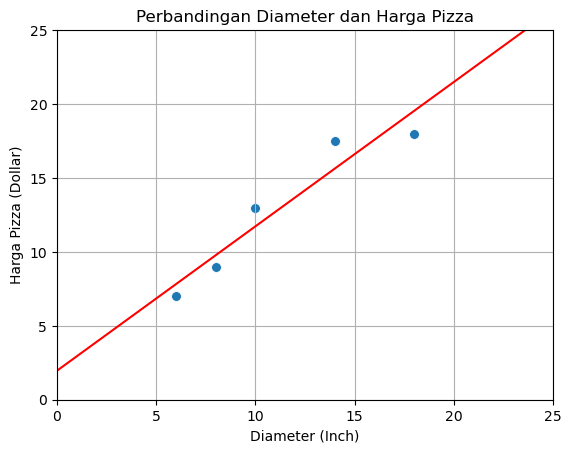

In [23]:
# kita panggil data X dan y dari pizza_df
ax = sns.scatterplot(data=pizza_df, x='diameter', y='harga', s=50)

# tampilkan garis linear reggresion hasil training
# - untuk garis lurus, r untuk warna merah
ax.plot(X_vis, y_vis, '-r')

# tambahan dalam visualisasi
ax.set(
    title = 'Perbandingan Diameter dan Harga Pizza',
    xlabel = 'Diameter (Inch)',
    ylabel = 'Harga Pizza (Dollar)',
    xlim = (0, 25),
    ylim = (0, 25)
)

# bergaris
ax.grid(True)